# Penugasan Pengolahan Citra
## JOBSHEET 05: MENGUKUR KEMIRIPAN CITRA DAN PENERAPANNYA DALAM PENGENALAN POLA 

**Nama:** Intan Nurul Faizia  
**NIM:** 3.34.23.2.11

**Dosen Pengampu:** Ir. Prayitno, S.ST., M.T., Ph.D.  
**Program Studi:** STR Teknologi Rekayasa Komputer  
**Politeknik Negeri Semarang**

---
## Penugasan F No. 3 — CBIR dengan Fitur Rata-rata Warna (Mean RGB)

**Tujuan:** Mengganti fitur histogram dengan vektor 3D rata-rata warna (mean R, G, B) dan menggunakan Jarak Euclidean. Lalu membandingkan hasilnya dengan histogram.

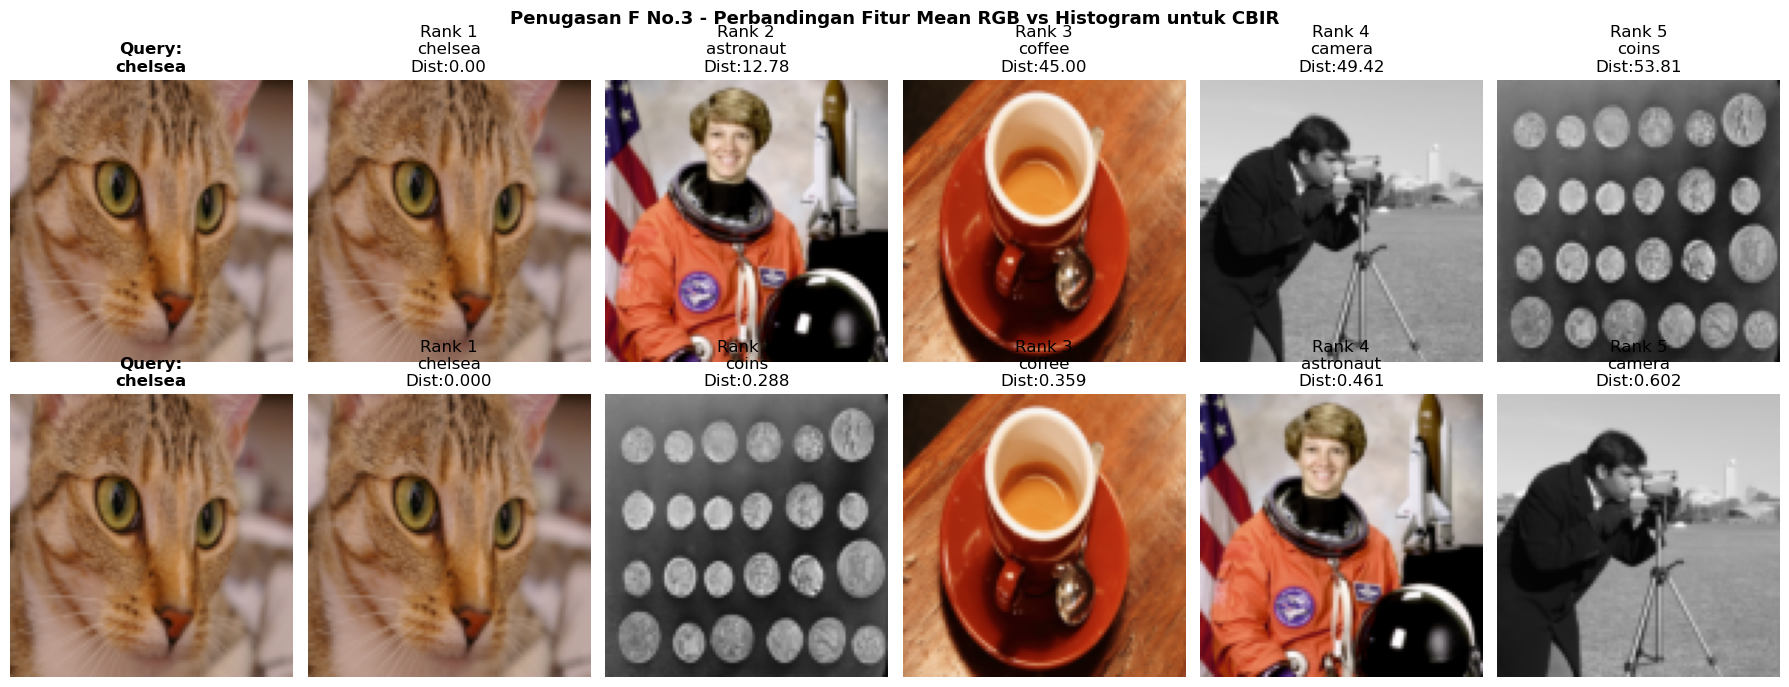

=== Mean RGB + Euclidean ===
Rank 1: chelsea      | Dist: 0.0000 | Mean RGB: (147.7, 111.4, 86.8)
Rank 2: astronaut    | Dist: 12.7762 | Mean RGB: (141.6, 105.8, 96.5)
Rank 3: coffee       | Dist: 45.0028 | Mean RGB: (158.6, 85.8, 51.5)
Rank 4: camera       | Dist: 49.4164 | Mean RGB: (129.1, 129.1, 129.1)
Rank 5: coins        | Dist: 53.8087 | Mean RGB: (96.9, 96.9, 96.9)

=== Histogram RGB + Cosine ===
Rank 1: chelsea      | Dist: 0.0000
Rank 2: coins        | Dist: 0.2879
Rank 3: coffee       | Dist: 0.3593
Rank 4: astronaut    | Dist: 0.4612
Rank 5: camera       | Dist: 0.6020


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_ubyte
from scipy.spatial import distance

# ===================== FUNGSI FITUR =====================
def mean_color_feature(image):
    """Ekstrak fitur rata-rata warna (mean R, G, B) sebagai vektor 3D."""
    mean_r = np.mean(image[:,:,0])
    mean_g = np.mean(image[:,:,1])
    mean_b = np.mean(image[:,:,2])
    return np.array([mean_r, mean_g, mean_b])

def calculate_rgb_histogram(image, bins=16):
    """Ekstrak fitur histogram RGB gabungan."""
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist = np.concatenate((hist_r, hist_g, hist_b)).astype(float)
    return hist / hist.sum()

# ===================== SIAPKAN DATABASE =====================
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_mean_feats = []
database_hist_feats = []

for name in image_db_names:
    img = getattr(data, name)()
    if img.ndim == 2:
        img = color.gray2rgb(img)
    img_resized = img_as_ubyte(transform.resize(img, (100, 100), anti_aliasing=True))
    database_images.append(img_resized)
    database_mean_feats.append(mean_color_feature(img_resized))
    database_hist_feats.append(calculate_rgb_histogram(img_resized))

# ===================== QUERY =====================
query_name  = "chelsea"
query_idx   = image_db_names.index(query_name)
query_image = database_images[query_idx]
query_mean  = database_mean_feats[query_idx]
query_hist  = database_hist_feats[query_idx]

# ===================== HITUNG JARAK =====================
# Metode 1: Euclidean pada Mean RGB
dist_mean = [distance.euclidean(query_mean, f) for f in database_mean_feats]
sorted_mean = np.argsort(dist_mean)

# Metode 2: Cosine pada Histogram
dist_hist = [distance.cosine(query_hist, f) for f in database_hist_feats]
sorted_hist = np.argsort(dist_hist)

# ===================== VISUALISASI PERBANDINGAN =====================
fig, axes = plt.subplots(2, len(database_images) + 1, figsize=(18, 7))

# Baris 1: Mean RGB
axes[0, 0].imshow(query_image)
axes[0, 0].set_title(f'Query:\n{query_name}', fontweight='bold')
axes[0, 0].axis('off')

for rank, idx in enumerate(sorted_mean):
    axes[0, rank+1].imshow(database_images[idx])
    axes[0, rank+1].set_title(f'Rank {rank+1}\n{image_db_names[idx]}\nDist:{dist_mean[idx]:.2f}')
    axes[0, rank+1].axis('off')

axes[0, 0].set_ylabel('Mean RGB\n(Euclidean)', fontsize=11, fontweight='bold')

# Baris 2: Histogram
axes[1, 0].imshow(query_image)
axes[1, 0].set_title(f'Query:\n{query_name}', fontweight='bold')
axes[1, 0].axis('off')

for rank, idx in enumerate(sorted_hist):
    axes[1, rank+1].imshow(database_images[idx])
    axes[1, rank+1].set_title(f'Rank {rank+1}\n{image_db_names[idx]}\nDist:{dist_hist[idx]:.3f}')
    axes[1, rank+1].axis('off')

axes[1, 0].set_ylabel('Histogram RGB\n(Cosine)', fontsize=11, fontweight='bold')

plt.suptitle('Penugasan F No.3 - Perbandingan Fitur Mean RGB vs Histogram untuk CBIR',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== RINGKASAN =====================
print("=== Mean RGB + Euclidean ===")
for rank, idx in enumerate(sorted_mean):
    feat = database_mean_feats[idx]
    print(f"Rank {rank+1}: {image_db_names[idx]:<12} | Dist: {dist_mean[idx]:.4f} | Mean RGB: ({feat[0]:.1f}, {feat[1]:.1f}, {feat[2]:.1f})")

print("\n=== Histogram RGB + Cosine ===")
for rank, idx in enumerate(sorted_hist):
    print(f"Rank {rank+1}: {image_db_names[idx]:<12} | Dist: {dist_hist[idx]:.4f}")

---
## Penugasan F No. 4 — Template Matching: Uji Invariansi Rotasi & Skala

**Tujuan:** Membuktikan bahwa `match_template` standar TIDAK invariant terhadap rotasi dan perubahan skala, dengan cara mencoba template yang dirotasi dan diubah ukurannya.

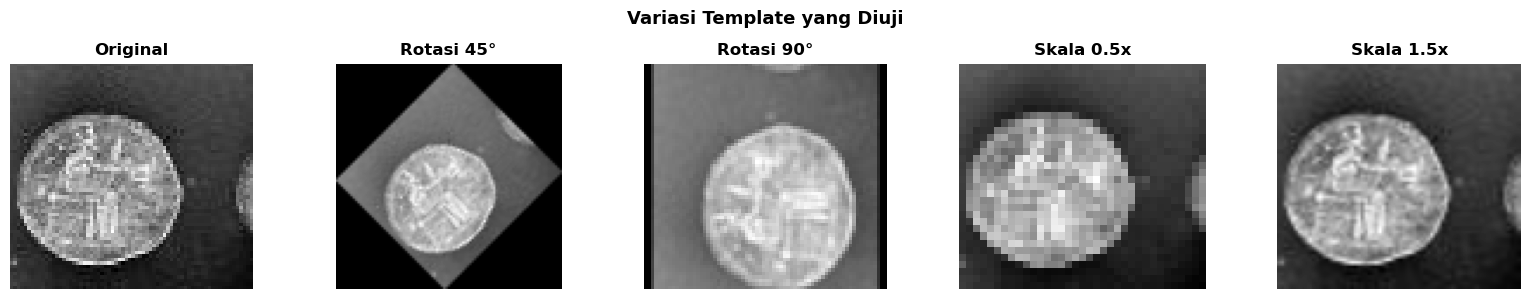

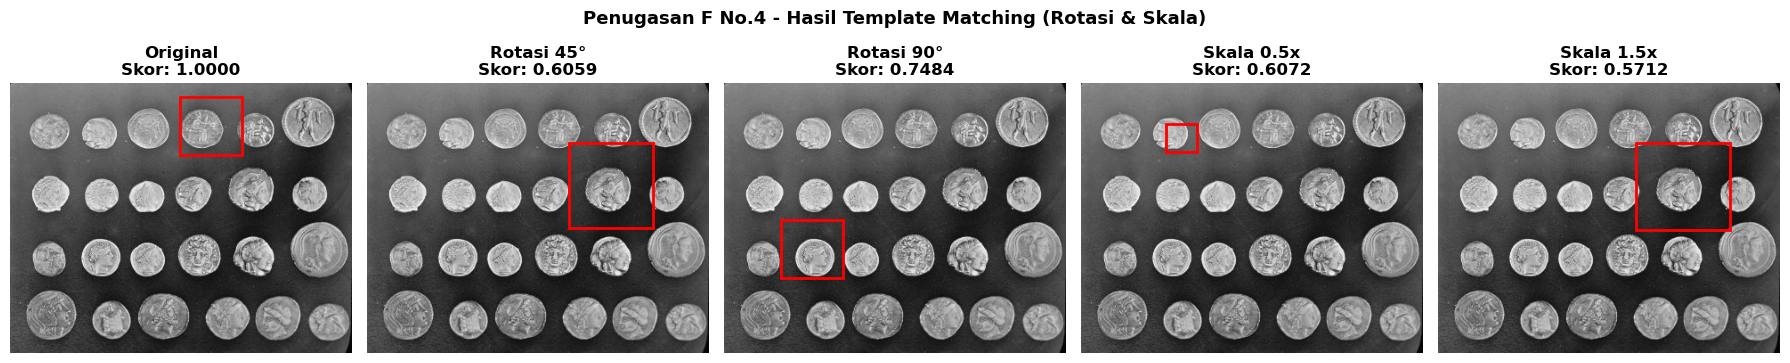

=== Skor Template Matching ===
Variasi                Skor Max Keterangan
-------------------------------------------------------
Original                 1.0000  Referensi (skor tertinggi)
Rotasi 45°               0.6059  Turun
Rotasi 90°               0.7484  Turun
Skala 0.5x               0.6072  Turun
Skala 1.5x               0.5712  Turun

Kesimpulan: match_template TIDAK invariant terhadap rotasi dan perubahan skala.
Skor menurun drastis ketika template dirotasi atau ukurannya berbeda.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.feature import match_template

# ===================== LOAD CITRA & TEMPLATE ASLI =====================
image    = data.coins()
template = image[15:80, 190:260]   # Template asli (koin)

# ===================== BUAT VARIASI TEMPLATE =====================
# 1. Template dirotasi 45 derajat
template_rot45  = transform.rotate(template, angle=45,  resize=True)

# 2. Template dirotasi 90 derajat
template_rot90  = transform.rotate(template, angle=90,  resize=False)

# 3. Template diperkecil (skala 0.5x)
h, w = template.shape
template_small  = transform.resize(template, (h//2, w//2), anti_aliasing=True)

# 4. Template diperbesar (skala 1.5x)
template_large  = transform.resize(template, (int(h*1.5), int(w*1.5)), anti_aliasing=True)

# ===================== TEMPLATE MATCHING SEMUA VARIASI =====================
def get_match_info(img, tmpl):
    """Jalankan template matching dan kembalikan hasil beserta koordinat terbaik."""
    result = match_template(img, tmpl)
    ij     = np.unravel_index(np.argmax(result), result.shape)
    x, y   = ij[::-1]
    score  = result.max()
    return result, x, y, score

res_orig,  x0, y0, score0 = get_match_info(image, template)
res_rot45, x1, y1, score1 = get_match_info(image, template_rot45)
res_rot90, x2, y2, score2 = get_match_info(image, template_rot90)
res_small, x3, y3, score3 = get_match_info(image, template_small)
res_large, x4, y4, score4 = get_match_info(image, template_large)

# ===================== VISUALISASI TEMPLATE =====================
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
titles = ['Original', 'Rotasi 45°', 'Rotasi 90°', 'Skala 0.5x', 'Skala 1.5x']
tmpls  = [template, template_rot45, template_rot90, template_small, template_large]
for ax, tmpl, title in zip(axes, tmpls, titles):
    ax.imshow(tmpl, cmap='gray')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')
plt.suptitle('Variasi Template yang Diuji', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== VISUALISASI HASIL MATCHING =====================
fig2, axes2 = plt.subplots(1, 5, figsize=(18, 4))
results = [res_orig, res_rot45, res_rot90, res_small, res_large]
coords  = [(x0,y0),(x1,y1),(x2,y2),(x3,y3),(x4,y4)]
scores  = [score0, score1, score2, score3, score4]

for ax, res, (x,y), sc, title in zip(axes2, results, coords, scores, titles):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'{title}\nSkor: {sc:.4f}', fontweight='bold')
    ax.axis('off')
    # Gambar kotak di lokasi terbaik
    rh, rw = tmpls[titles.index(title)].shape[:2]
    rect = plt.Rectangle((x, y), rw, rh, edgecolor='red', facecolor='none', lw=2)
    ax.add_patch(rect)

plt.suptitle('Penugasan F No.4 - Hasil Template Matching (Rotasi & Skala)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== RINGKASAN SKOR =====================
print("=== Skor Template Matching ===")
print(f"{'Variasi':<20} {'Skor Max':>10} {'Keterangan'}")
print("-" * 55)
print(f"{'Original':<20} {score0:>10.4f}  Referensi (skor tertinggi)")
print(f"{'Rotasi 45°':<20} {score1:>10.4f}  {'Turun' if score1 < score0 else 'Sama'}")
print(f"{'Rotasi 90°':<20} {score2:>10.4f}  {'Turun' if score2 < score0 else 'Sama'}")
print(f"{'Skala 0.5x':<20} {score3:>10.4f}  {'Turun' if score3 < score0 else 'Sama'}")
print(f"{'Skala 1.5x':<20} {score4:>10.4f}  {'Turun' if score4 < score0 else 'Sama'}")
print()
print("Kesimpulan: match_template TIDAK invariant terhadap rotasi dan perubahan skala.")
print("Skor menurun drastis ketika template dirotasi atau ukurannya berbeda.")